# 🌊 Disaster Relief AI - ML Pipeline

## 1. Import Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving flood.csv to flood.csv


In [3]:
df = pd.read_csv("flood.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## 3. Inspect Dataset


In [4]:
# Display first 5 rows
print("First 5 Rows:")
display(df.head())

# Shape of the dataset
print("\nDataset Shape:")
print(df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
display(df.dtypes)

# Basic statistics
print("\nStatistical Summary:")
display(df.describe())

# Missing values
print("\nMissing Values:")
display(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

First 5 Rows:


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475



Dataset Shape:
(50000, 21)

Columns:
['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'FloodProbability']

Data Types:


,0
MonsoonIntensity,int64
TopographyDrainage,int64
RiverManagement,int64
Deforestation,int64
Urbanization,int64
ClimateChange,int64
DamsQuality,int64
Siltation,int64
AgriculturalPractices,int64
Encroachments,int64



Statistical Summary:


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,4.991480,4.984100,5.01594,5.008480,4.989060,4.988340,5.01536,4.988600,5.006120,5.006380,...,5.006060,4.999920,4.984220,4.97982,4.988200,4.984980,5.00512,4.994360,4.990520,0.499660
std,2.236834,2.246488,2.23131,2.222743,2.243159,2.226761,2.24500,2.232642,2.234588,2.241633,...,2.238107,2.247101,2.227741,2.23219,2.231134,2.238279,2.23176,2.230011,2.246075,0.050034
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.285000
25%,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,3.000000,0.465000
50%,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000,0.500000
75%,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.00000,6.000000,6.000000,0.535000
max,16.000000,18.000000,16.00000,17.000000,17.000000,17.000000,16.00000,16.000000,16.000000,18.000000,...,17.000000,17.000000,16.000000,16.00000,17.000000,19.000000,22.00000,16.000000,16.000000,0.725000



Missing Values:


,0
MonsoonIntensity,0
TopographyDrainage,0
RiverManagement,0
Deforestation,0
Urbanization,0
ClimateChange,0
DamsQuality,0
Siltation,0
AgriculturalPractices,0
Encroachments,0



Duplicate Rows:
0


## 4. Data Validation

We first validated the dataset for completeness, duplicates, and data types. Since it was already clean, we proceeded directly to EDA and model development.


## 5. Exploratory Data Analysis (EDA)

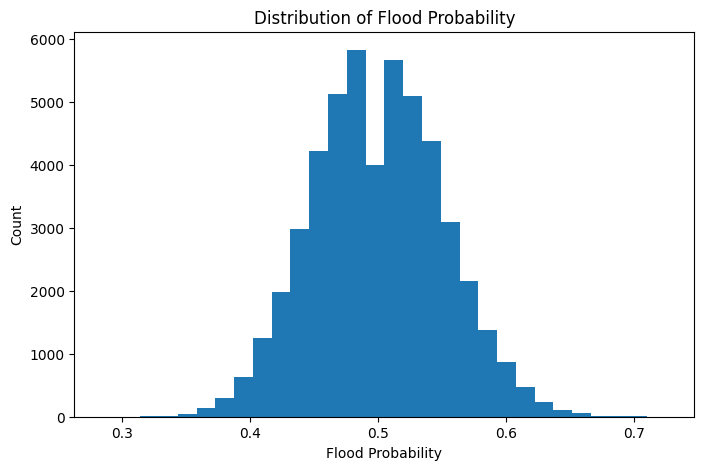

In [5]:
plt.figure(figsize=(8,5))
plt.hist(df["FloodProbability"], bins=30)

plt.title("Distribution of Flood Probability")
plt.xlabel("Flood Probability")
plt.ylabel("Count")

plt.show()

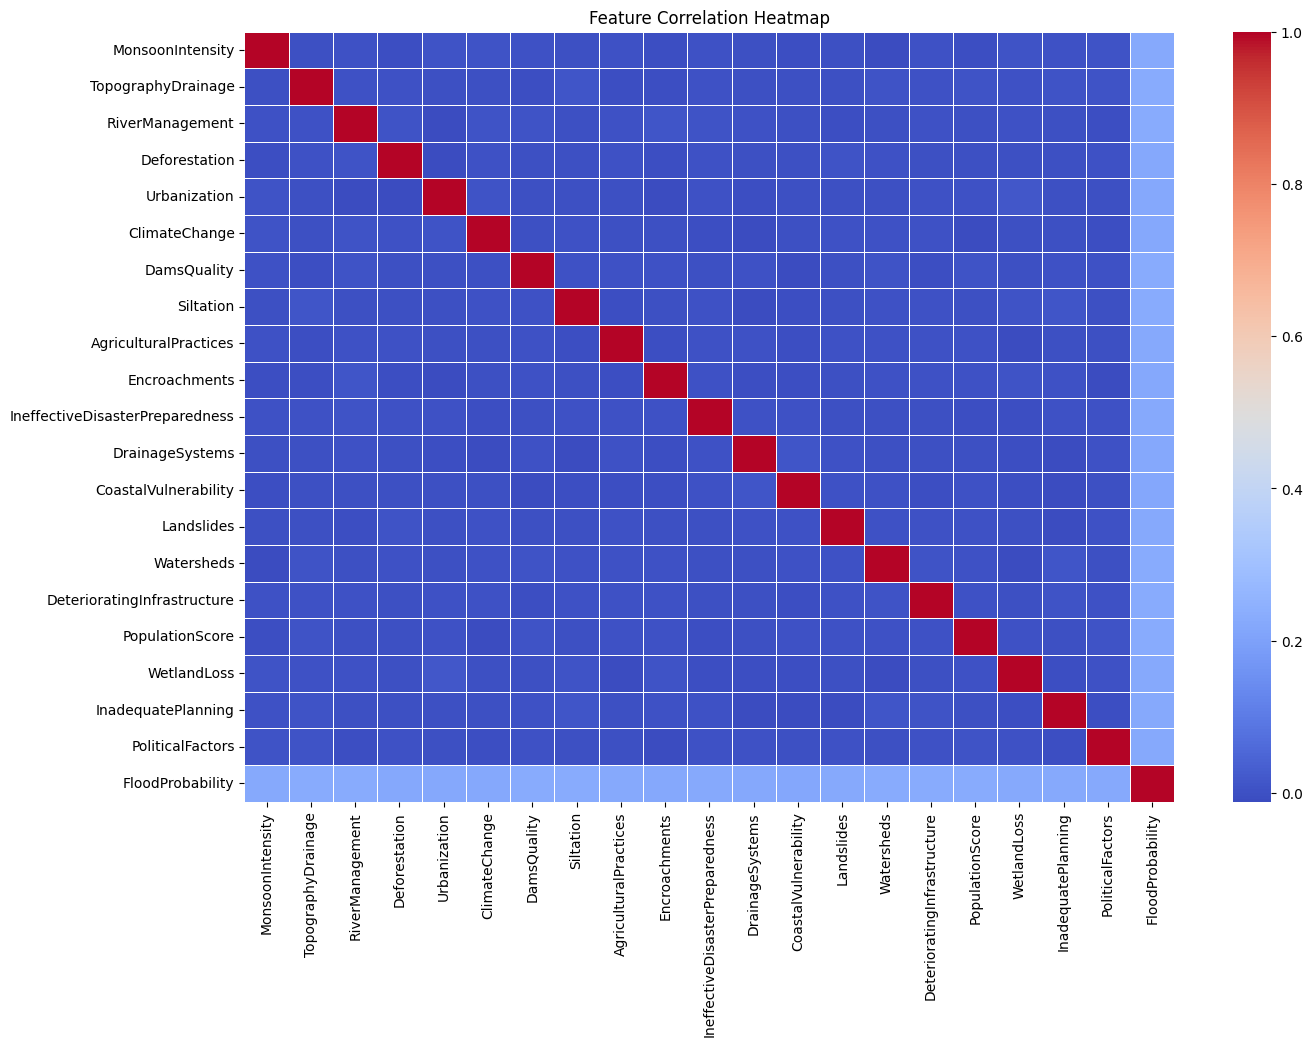

In [6]:
import seaborn as sns

plt.figure(figsize=(15,10))

sns.heatmap(df.corr(),
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Feature Correlation Heatmap")

plt.show()

In [7]:
correlation = df.corr()["FloodProbability"].sort_values(ascending=False)

print(correlation)

FloodProbability                   1.000000
DeterioratingInfrastructure        0.229444
TopographyDrainage                 0.229414
RiverManagement                    0.228917
Watersheds                         0.228152
DamsQuality                        0.227467
PopulationScore                    0.226928
Siltation                          0.226544
IneffectiveDisasterPreparedness    0.225126
PoliticalFactors                   0.225009
MonsoonIntensity                   0.224081
WetlandLoss                        0.223732
InadequatePlanning                 0.223329
Landslides                         0.222991
AgriculturalPractices              0.221846
ClimateChange                      0.220986
Urbanization                       0.220867
Deforestation                      0.220237
Encroachments                      0.218259
DrainageSystems                    0.217895
CoastalVulnerability               0.215187
Name: FloodProbability, dtype: float64


## 6. Feature Engineering

In [8]:
# Features (Input)
X = df.drop("FloodProbability", axis=1)

# Target (Output)
y = df["FloodProbability"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

Features Shape: (50000, 20)
Target Shape: (50000,)

Feature Columns:
['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors']


## 7. Train-Test Split

In [9]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (40000, 20)
Testing Data: (10000, 20)


## 8. Model Training

In [10]:
# Train Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest Model Trained Successfully!")

✅ Random Forest Model Trained Successfully!


## 9. Model Evaluation

In [11]:
# Predict on test data
y_pred = rf_model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("========== MODEL PERFORMANCE ==========")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

========== MODEL PERFORMANCE ==========
MAE  : 0.0205
MSE  : 0.0007
RMSE : 0.0260
R² Score : 0.7295


10.Feature Importance

,Feature,Importance
1,TopographyDrainage,0.053020
6,DamsQuality,0.052789
19,PoliticalFactors,0.052384
10,IneffectiveDisasterPreparedness,0.051635
16,PopulationScore,0.051615
2,RiverManagement,0.051396
13,Landslides,0.050995
8,AgriculturalPractices,0.050673
15,DeterioratingInfrastructure,0.050642
14,Watersheds,0.050545


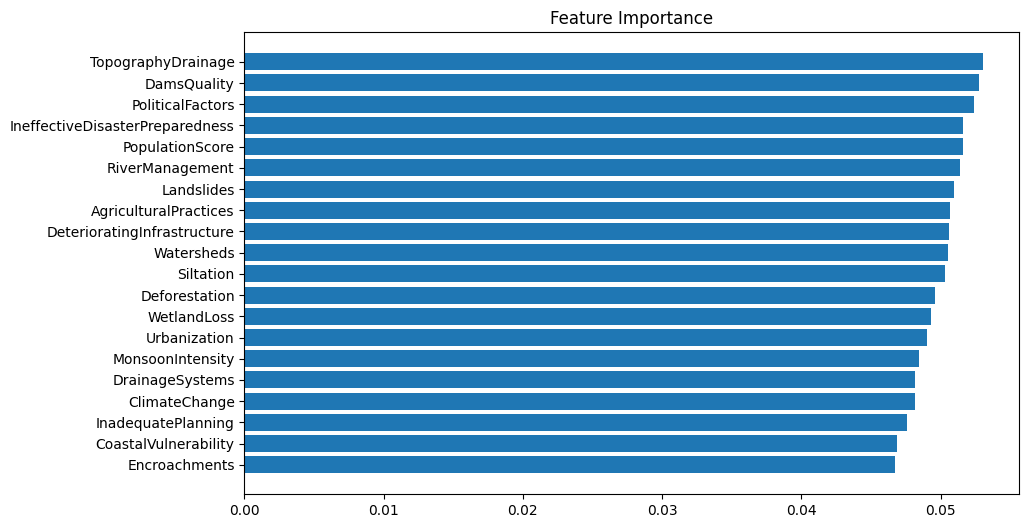

In [12]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.show()

## 10. Save Model

In [13]:
joblib.dump(rf_model, "model.pkl")

print(" Model Saved Successfully!")

 Model Saved Successfully!


In [14]:
import os

print(os.listdir())

['.config', 'flood.csv', 'model.pkl', 'sample_data']


In [15]:
from google.colab import files

files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Test Prediction

In [16]:
sample = X_test.iloc[[0]]

prediction = rf_model.predict(sample)

print("Predicted Flood Probability :", prediction[0])
print("Actual Flood Probability    :", y_test.iloc[0])

Predicted Flood Probability : 0.4637499999999998
Actual Flood Probability    : 0.455
